# Todo: 
* make it so that the level choice you make exports the right lvl label to the model output and scdata and everywhere else

In [1]:
import cell2location
import pandas as pd
import numpy as np 
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl


from matplotlib import rcParams

rcParams['pdf.fonttype'] = 42 # enables correct plotting of text for PDFs
from pathlib import Path
from scipy import sparse # Dealing with adata data dyptes numbers

import torch
torch.set_float32_matmul_precision("high")  # or "medium"
# to deal with this warning
# You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. 
# To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` 
# which will trade-off precision for performance. For more details, read 
# https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision

In [2]:
from cell2location.utils.filtering import filter_genes
from cell2location.models import RegressionModel

## SC: GPU

In [5]:
# SC for GPU
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version (torch):", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("Current device:", torch.cuda.current_device())
    print("Device name:", torch.cuda.get_device_name(0))


Torch version: 2.7.1
CUDA available: False
CUDA version (torch): None
GPU count: 0


In [7]:
# import torch, scvi
# print(torch.__version__, torch.cuda.is_available(), torch.cuda.get_device_name(0))

# Data

## Locations

In [25]:
# Selected level of annotation for training the model.
level = 1
levels = ["cell_type_lvl1", "cell_type_lvl2", "cell_type_lvl3"]

level_short = {
    "cell_type_lvl1": "lvl1",
    "cell_type_lvl2": "lvl2",
    "cell_type_lvl3": "lvl3",
}

In [26]:

current_level = levels[level]
lvl_name_short =level_short[current_level]

In [27]:
# Project folder
proj_folder   = Path("/Users/janzules/Roselab/Spatial/CAR_T/")
c2l_folder    = proj_folder / "Results/cell2location/"

# Files for training and mapping
input_folder  = c2l_folder / "C2L_inputs"

figures_folder = proj_folder / "figures/cell2location/training"


ref_loc       = input_folder / "ref_adata_c2l_model.h5ad"
# spatial_loc   = input_folder / "spatial_adata_c2l_model.h5ad"

# Output location - Not sure what these are for
ref_run_name   = c2l_folder / f"reference_signatures_{lvl_name_short}"
run_name       = c2l_folder / f"c2l_{lvl_name_short}"

# After training
adata_out     = input_folder / f"sc_with_signatures_{lvl_name_short}.h5ad"

In [4]:
# Load data
adata_ref = sc.read_h5ad(ref_loc)

## Processing Data

In [5]:
# ensure that the data is in the correct format for cell2location
# needs to be: type(adata_ref.X), adata_ref.X.dtype
adata_ref.X = adata_ref.X.tocsr()
adata_ref.X.data = adata_ref.X.data.astype(np.float32)

type(adata_ref.X), adata_ref.X.dtype

(scipy.sparse._csr.csr_matrix, dtype('float32'))

# C2L

With Alice's annotations we should use these labels:

* cell_type_lvl1
* cell_type_lvl2
* cell_type_lvl3

## Selecting levels

/Users/janzules/miniforge3/envs/spatial_cpu_py311/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


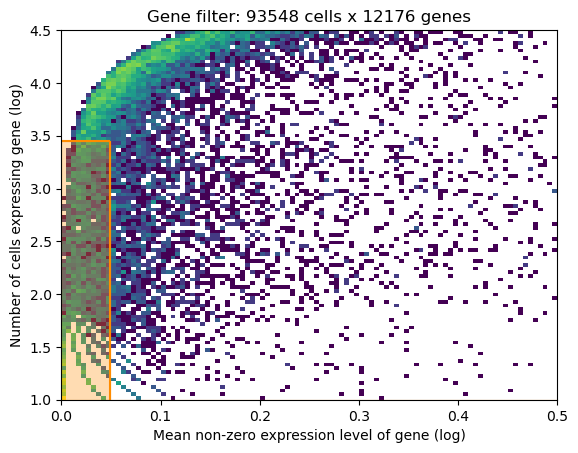

In [7]:
selected = filter_genes(adata_ref, cell_count_cutoff=5, cell_percentage_cutoff2=0.03, nonz_mean_cutoff=1.12)

In [8]:
# filter the object
adata_ref = adata_ref[:, selected].copy()

## Training

In [ ]:
# prepare anndata for the regression model
cell2location.models.RegressionModel.setup_anndata(adata=adata_ref,
                        # 10X reaction / sample / batch
                        batch_key='Library',
                        # cell type, covariate used for constructing signatures
                        labels_key=current_level
                       )

In [23]:
# create the regression model
from cell2location.models import RegressionModel
mod = RegressionModel(adata_ref)

# view anndata_setup as a sanity check
mod.view_anndata_setup()

Anndata setup with scvi-tools version 1.4.1.

Setup via `RegressionModel.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': 'Library',
│   'labels_key': 'cell_type_lvl2',
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │  29   │
│         n_cells          │ 93548 │
│ n_extra_categorical_covs │   0   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │  19   │
│          n_vars          │ 12176 │
└──────────────────────────┴───────┘

               Data Registry                
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃    scvi-tools Location    ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │          adata.X          │
│    batch     │ adata.obs['_scvi_batch']  │
│    ind_x     │   adata.obs['_indices']   │
│    labels    │ adata.obs['_scvi_labels'] │
└──────────────┴───────────────────────────┘

                   batch State Registry                    
┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃   Source Location    ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['Library'] │   56948    │          0          │
│                      │   56949    │          1          │
│                      │   56950    │          2          │
│                      │   56951    │          3          │
│                      │   56952    │          4          │
│                      │   56953    │          5          │
│                      │   56954    │          6          │
│                      │   56955    │          7          │
│                      │   56956    │          8          │
│                      │   56957    │          9          │
│                      │   56958    │         10          │
│                      │   56959    │         11          │
│                      │   56961    │         12          │
│                      │   56962    │         13          │
│                      │   56963    │         14          │
│                      │   56964    │         15          │
│                      │   56965    │         16          │
│                      │   56966    │         17          │
│                      │   56967    │         18          │
│                      │   56968    │         19          │
│                      │   56969    │         20          │
│                      │   56970    │         21          │
│                      │   56971    │         22          │
│                      │   56972    │         23          │
│                      │   56973    │         24          │
│                      │   56974    │         25          │
│                      │   56975    │         26          │
│                      │   56976    │         27          │
│                      │   56977    │         28          │
└──────────────────────┴────────────┴─────────────────────┘

                          labels State Registry                          
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃       Source Location       ┃    Categories     ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['cell_type_lvl2'] │         B         │          0          │
│                             │       CD4_T       │          1          │
│                             │       CD8_T       │          2          │
│                             │    Cancer_cell    │          3          │
│                             │  Classical_Mono   │          4          │
│                             │    Endothelial    │          5          │
│                             │    Erythrocyte    │          6          │
│                             │    Fibroblast     │          7          │
│                             │ Intermediate_Mac  │          8          │
│                             │    M1_like_Mac    │          9          │
│                             │    M2_like_Mac    │         10          │
│                             │    N1_like_Neu    │         11          │
│                             │    N2_like_Neu    │         12          │
│                             │        NK         │         13          │
│                             │        NKT        │         14          │
│                             │ Nonclassical_Mono │         15          │
│                             │       Treg        │         16          │
│                             │        cDC        │         17          │
│                             │        pDC        │         18          │
└─────────────────────────────┴───────────────────┴─────────────────────┘

In [24]:
mod.train(max_epochs=250)

/Users/janzules/miniforge3/envs/spatial_cpu_py311/lib/python3.11/site-packages/scvi/train/_trainrunner.py:86: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/Users/janzules/miniforge3/envs/spatial_cpu_py311/lib/python3.11/site-packages/lightning/pytorch/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/janzules/miniforge3/envs/spatial_cpu_py311/lib/python3.11/site-packages/lightning/pytorch/trainer/configuration_validator.py:68: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
/Users/janzules/miniforge3/envs/spatial_cpu_py311/lib/python3.11/site-packages/lightni

Training:   0%|          | 0/250 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=250` reached.


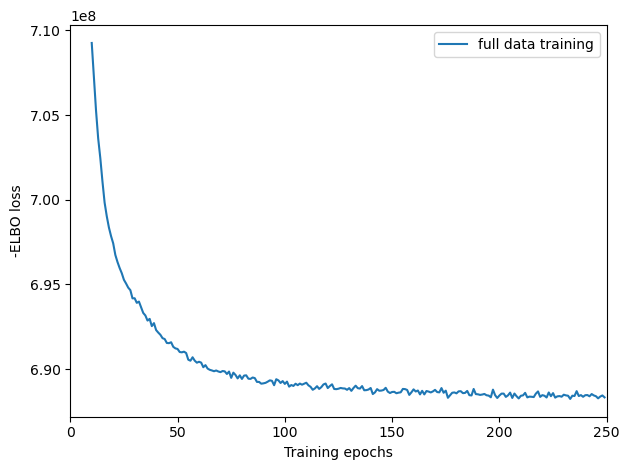

In [40]:
# plot ELBO loss history during training, removing first 100 epochs from the plot
mod.plot_history(10)
plt.legend(labels=['full data training'])

### Saving

In [29]:
# In this section, we export the estimated cell abundance (summary of the posterior distribution).
adata_ref = mod.export_posterior(
    adata_ref, sample_kwargs={'num_samples': 1000, 'batch_size': 2500}
)

/Users/janzules/miniforge3/envs/spatial_cpu_py311/lib/python3.11/site-packages/scvi/model/base/_pyromixin.py:499: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
  _, _, device = parse_device_args(


Sampling local variables, batch:   0%|          | 0/38 [00:00<?, ?it/s]

Sampling global variables, sample:   0%|          | 0/999 [00:00<?, ?it/s]

In [30]:
# Save model
mod.save(f"{ref_run_name}", overwrite=True) # ref_run_name created at location

# Save anndata object with results
# adata_file = f"{ref_run_name}/sc.h5ad"
adata_ref.write(adata_out)
# adata_file

In [ ]:
# adata_ref = mod.export_posterior(
#     adata_ref,
#     add_to_varm=["means", "stds", "q05", "q95"],
#     sample_kwargs={"batch_size": 2500, "num_samples": 200},
# )


/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/janzules/mamba_envs/spatial_gpu_py311/lib/pyth ...


Sampling local variables, batch:   0%|          | 0/55 [00:00<?, ?it/s]

Sampling global variables, sample:   0%|          | 0/199 [00:00<?, ?it/s]

In [31]:
# Should exist after export_posterior:
print("factor_names:", len(adata_ref.uns["mod"]["factor_names"]))
print("varm keys:", list(adata_ref.varm.keys())[:10])
print("has means_per_cluster_mu_fg:", "means_per_cluster_mu_fg" in adata_ref.varm)


factor_names: 19
varm keys: ['means_per_cluster_mu_fg', 'stds_per_cluster_mu_fg', 'q05_per_cluster_mu_fg', 'q95_per_cluster_mu_fg']
has means_per_cluster_mu_fg: True


In [ ]:
# adata_ref.write(f"{ref_run_name}/sc_with_signatures.h5ad")

/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/anndata/_io/utils.py:243: FutureWarning: Forward slashes will be disallowed in h5 stores in the next minor release
  return func(*args, **kwargs)


### QC

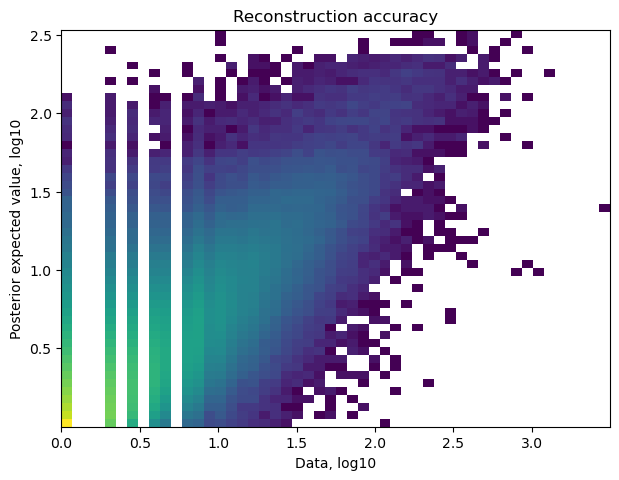

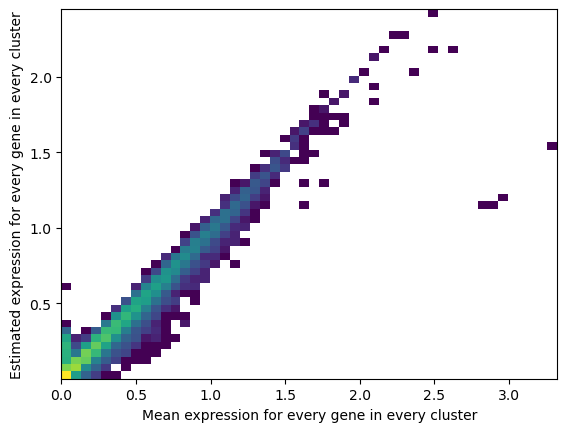

In [39]:
mod.plot_QC()